In [1]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import krippendorff

df = pd.read_csv("../Datasets/pilot1.csv", delimiter=",")
df = df.drop(columns="id")
df.head()

,text,timestamp_tamara,flagged_tamara,comment_tamara,tag_tamara,timestamp_anze,flagged_anze,comment_anze,tag_anze,timestamp_katja,flagged_katja,comment_katja,tag_katja,rev_tamara,rev_anze,rev_katja,final_tag
0,"Tako kot sem uvodoma povedal, še vedno mislim,...",2023-02-23 10:08:33,NaN,NaN,P_Neutral,2023-02-23 10:05:56,NaN,It is posible to see documents,P_Neutral,1677143150,NaN,"Statement, but expresses positive hope",P_Neutral,NaN,NaN,NaN,P_Neutral
1,"Manj ko je beguncev, večji je odpor pred temi ...",2023-02-23 10:09:11,NaN,No direct opinion by the speaker.,N_Neutral,2023-02-23 10:06:26,NaN,NaN,Negative,1677143163,NaN,NaN,Negative,No direct opinion by the speaker.,"Opinion not expressed directly, but implied","Opinion not expressed directly, but implied",Negative
2,"Drugo vprašanje, ki ste ga izpostavili, je vpr...",2023-02-23 10:09:34,NaN,NaN,P_Neutral,2023-02-23 10:07:22,NaN,NaN,Positive,1677143249,NaN,"Neutral, factual statement",NaN,No direct opinion by the speaker.,Positive topic (socialni dialog),"Neutral, factual statement, not direct opinion",P_Neutral
3,Če se lahko tako izrazim; »pravica« biti deleg...,2023-02-23 10:10:37,NaN,Sarcasm.,N_Neutral,2023-02-23 10:09:08,NaN,Positive thinking,P_Neutral,1677143451,NaN,Slight sarcasm,N_Neutral,Sarcasm,Because position will be formed,"Sarcasm, otherwise neutral",N_Neutral(S)
4,"Seveda, kjerkoli zavrtajo v Prekmurju, tam pri...",2023-02-23 10:10:57,NaN,Sarcasm.,N_Neutral,2023-02-23 10:10:21,NaN,S,P_Neutral,1677143466,NaN,Sarcasm,NaN,Sarcasm,Sarcasm,Degrading connotation,N_Neutral(S)


In [2]:
#Handle the sarcasm-coded values; i.e. replace label(S) -> label.
for col in df.columns:
    if col.startswith("tag_") or col.startswith("final_"):
        df[col] = df[col].apply(
            lambda x: x.strip().replace("(S)", "") if isinstance(x, str) and "(S)" in x else x
        )

In [3]:
#Check if replacement worked and the remaining labels correspond to the annotation categories 
print(df["tag_tamara"].unique())
print(df["tag_katja"].unique())
print(df["tag_anze"].unique())

print(df['final_tag'].unique())

['P_Neutral' 'N_Neutral' 'Negative' nan 'Positive' 'M_Negative'
 'M_Positive']
['P_Neutral' 'Negative' nan 'N_Neutral' 'Positive' 'M_Negative'
 'M_Positive']
['P_Neutral' 'Negative' 'Positive' 'M_Negative' 'N_Neutral' 'M_Positive'
 nan]
['P_Neutral' 'Negative' 'N_Neutral' 'M_Negative' 'Positive' 'M_Positive'
 'N_Negative']


### Krippendorffs Alpha for the original 6-class schema

In [4]:
tag_cols = ['tag_tamara', 'tag_katja', 'tag_anze']
tags = df[tag_cols]
tags.head()

,tag_tamara,tag_katja,tag_anze
0,P_Neutral,P_Neutral,P_Neutral
1,N_Neutral,Negative,Negative
2,P_Neutral,NaN,Positive
3,N_Neutral,N_Neutral,P_Neutral
4,N_Neutral,NaN,P_Neutral


In [5]:
unique_labels = pd.unique(tags.values.ravel())

# Create a mapping of labels to consistent numeric codes
label_to_code = {label: idx for idx, label in enumerate(unique_labels)}

# Map the labels to numeric codes for all annotators
for col in tag_cols:
    df[col + '_code'] = df[col].map(label_to_code)


In [6]:
coded_cols = [col + '_code' for col in tag_cols]
data_array = df[coded_cols].to_numpy().T
alpha_value = krippendorff.alpha(reliability_data=data_array, level_of_measurement='nominal')

print(f"Krippendorff's alpha (nominal): {alpha_value}")

Krippendorff's alpha (nominal): 0.2565522535365722


In [7]:
labels = df["final_tag"].value_counts()
labels

final_tag
Negative      22
P_Neutral     11
N_Neutral      7
Positive       4
M_Negative     3
M_Positive     2
N_Negative     1
Name: count, dtype: int64

<Axes: ylabel='count'>

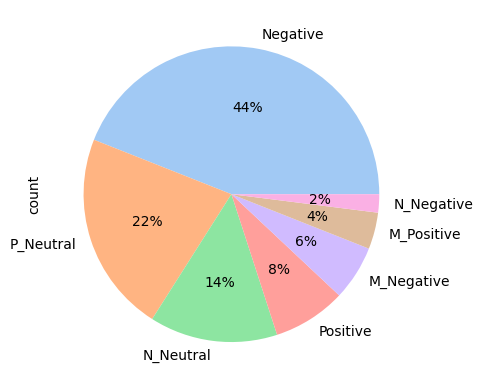

In [8]:
import seaborn as sns
color = sns.color_palette('pastel')
labels.plot(kind="pie", autopct='%1.0f%%', colors=color)

### Krippendorffs Alpha for the 3-class schema (Positive, Negative, Neutral)


In [9]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

for col in tag_cols:
    df[col + '_sent'] = df[col].map(mapping_3class)

In [10]:
columns = ['tag_tamara_sent', 'tag_katja_sent', 'tag_anze_sent']
sent = df[columns]
sent.head()

,tag_tamara_sent,tag_katja_sent,tag_anze_sent
0,Neutral,Neutral,Neutral
1,Neutral,Negative,Negative
2,Neutral,NaN,Positive
3,Neutral,Neutral,Neutral
4,Neutral,NaN,Neutral


In [11]:
sent_unique = pd.unique(sent.values.ravel())
sent_to_code = {label: idx for idx, label in enumerate(sent_unique)}

for col in columns:
    df[col + '_code'] = df[col].map(sent_to_code)

sent_cols = [col + '_code' for col in columns]

In [12]:
sent_array = df[sent_cols].to_numpy().T
alpha_sent = krippendorff.alpha(reliability_data=sent_array, level_of_measurement='nominal')

print(f"Krippendorff's alpha (nominal): {alpha_sent}")

Krippendorff's alpha (nominal): 0.2572852760736196
